In [1]:
print("tara")

tara


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

In [3]:
models = ["RNN", "LSTM", "GRU", "BiLSTM", "CNN+LSTM", "TD-CNN+LSTM"]

accuracy = [93.12, 96.98, 98.22, 97.83, 98.91, 97.74]

train_time = [25, 28, 27, 30, 31.5, 48.9]

params = [60000, 150000, 120000, 200000, 250000, 297290]

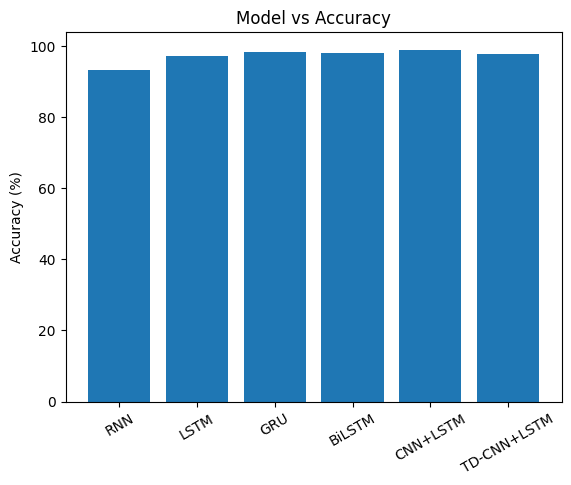

In [4]:
plt.figure()
plt.bar(models, accuracy)
plt.title("Model vs Accuracy")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()

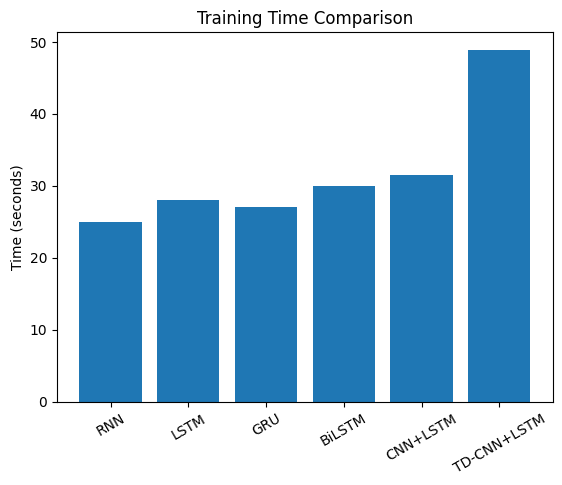

In [5]:
plt.figure()
plt.bar(models, train_time)
plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=30)
plt.show()

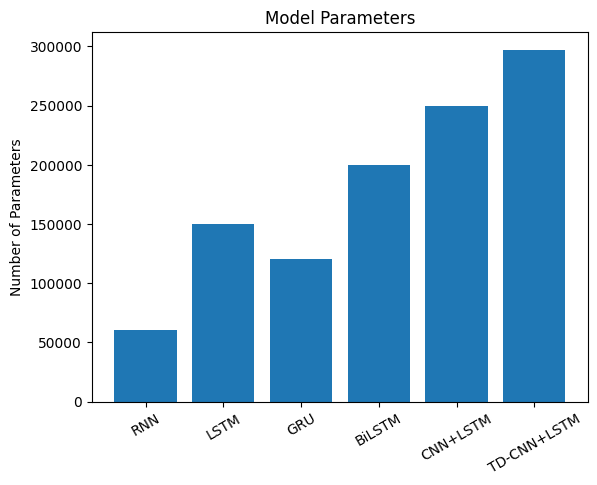

In [6]:
plt.figure()
plt.bar(models, params)
plt.title("Model Parameters")
plt.ylabel("Number of Parameters")
plt.xticks(rotation=30)
plt.show()

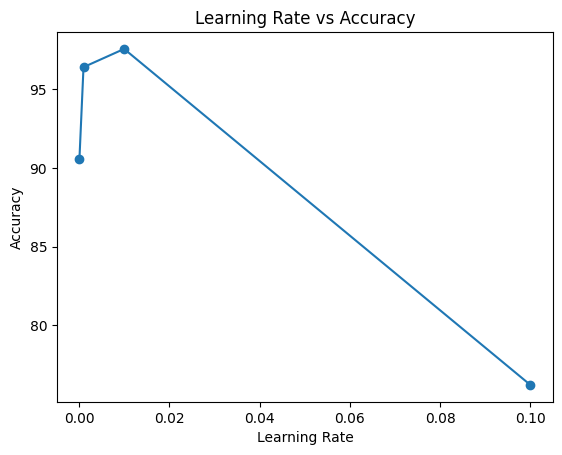

In [7]:
lrs = [0.1, 0.01, 0.001, 0.0001]
acc_lr = [76.20, 97.58, 96.42, 90.60]

plt.figure()
plt.plot(lrs, acc_lr, marker='o')
plt.title("Learning Rate vs Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.show()

In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.83MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.35MB/s]


In [14]:
class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm = nn.LSTM(64*7, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0,2,1,3).reshape(x.size(0), 7, -1)
        out,_ = self.lstm(x)
        return self.fc(out[:,-1,:])

In [15]:
model = CNN_LSTM().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(2):
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Model ready")

Model ready


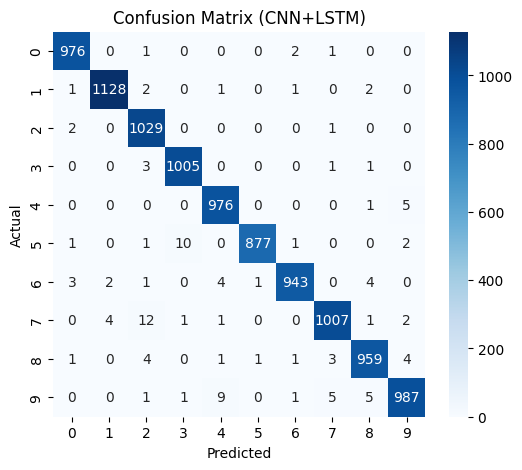

In [16]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (CNN+LSTM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

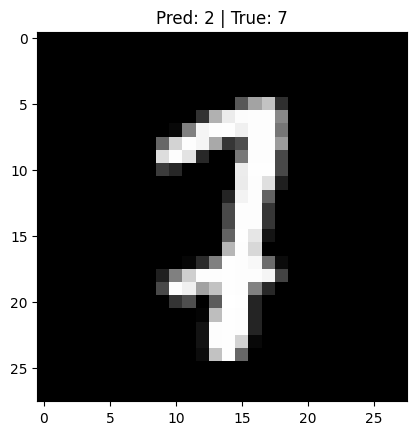

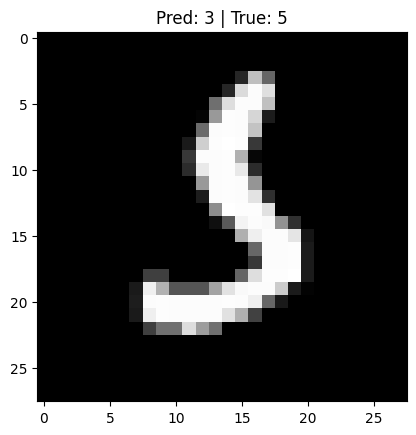

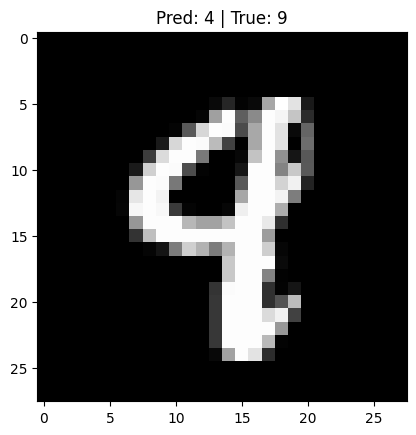

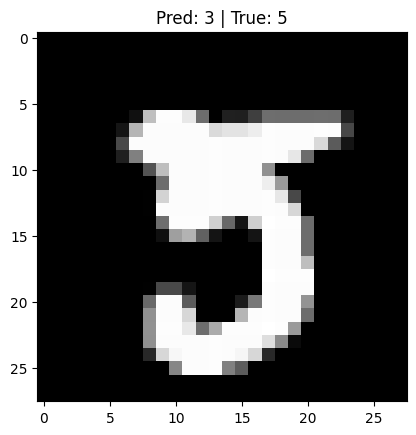

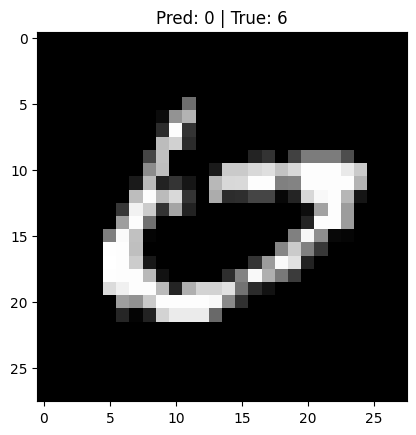

In [17]:
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs,1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                wrong_images.append(images[i].cpu())
                wrong_preds.append(preds[i].item())
                wrong_labels.append(labels[i].item())

for i in range(5):
    plt.imshow(wrong_images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {wrong_preds[i]} | True: {wrong_labels[i]}")
    plt.show()

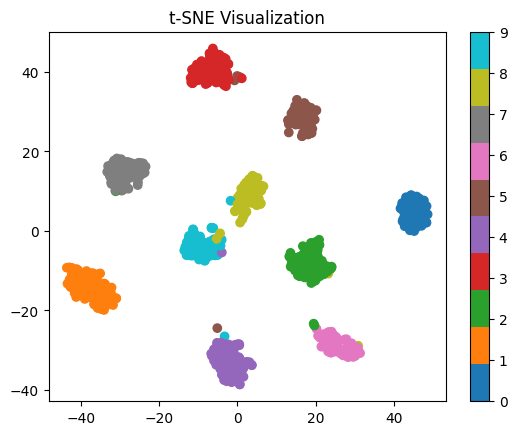

In [18]:
features = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        out = model(images)

        features.append(out.cpu())
        labels_list.append(labels)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(n_components=2)
reduced = tsne.fit_transform(features[:1000])

plt.figure()
plt.scatter(reduced[:,0], reduced[:,1], c=labels_list[:1000], cmap='tab10')
plt.colorbar()
plt.title("t-SNE Visualization")
plt.show()